In [ ]:
#importing all required python libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt #use to visualize dataset values
import seaborn as sns
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn import svm
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.cluster import DBSCAN#loading DBSCAN clustering
from sklearn.neighbors import KernelDensity #loading kernel density algorithms
from sklearn.decomposition import PCA #pca for dimension reduction
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error

In [ ]:
#class to normalize dataset values
scaler = MinMaxScaler(feature_range = (0, 1))
scaler1 = MinMaxScaler(feature_range = (0, 1))

In [ ]:
#loading and displaying cellular lte dataset
dataset = pd.read_csv("SRFG-v1.csv", nrows=10000)
dataset

,time,lat,long,ele,newpos,rsrq,cell_id,sinr,signal,pci,...,technology,rsrp,datarate,file,line,trip,predecessor,dlong,dlat,predecessor2
0,2018-01-15 16:43:52,47.847847,13.080113,505.1,True,-6.0,798470,28.0,5.0,468.0,...,LTE,-65.0,5554624.0,2018-01-15-1736,417,2018-01-15-1736,NaN,NaN,NaN,NaN
1,2018-01-15 16:43:53,47.848070,13.080318,505.2,True,-7.0,798470,24.0,5.0,468.0,...,LTE,-68.0,4814816.0,2018-01-15-1736,418,2018-01-15-1736,1.0,0.000205,0.000221,NaN
2,2018-01-15 16:43:54,47.848280,13.080542,505.5,True,-7.0,798470,22.0,5.0,468.0,...,LTE,-67.0,5081632.0,2018-01-15-1736,419,2018-01-15-1736,1.0,0.000223,0.000214,NaN
3,2018-01-15 16:43:55,47.848484,13.080778,505.7,True,-6.0,798470,22.0,5.0,468.0,...,LTE,-70.0,5506112.0,2018-01-15-1736,420,2018-01-15-1736,1.0,0.000237,0.000202,NaN
4,2018-01-15 16:43:56,47.848680,13.081034,505.8,True,-7.0,798470,17.0,5.0,468.0,...,LTE,-77.0,5518240.0,2018-01-15-1736,421,2018-01-15-1736,1.0,0.000256,0.000195,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2018-02-06 16:29:10,47.843945,13.295335,555.1,True,-16.0,421638,-3.0,1.0,198.0,...,LTE,-109.0,2219424.0,2018-02-06-1702,1557,2018-02-06-1702,1.0,0.000424,0.000019,NaN
9996,2018-02-06 16:29:11,47.843964,13.295760,555.2,True,-16.0,421638,-3.0,1.0,198.0,...,LTE,-106.0,2474112.0,2018-02-06-1702,1558,2018-02-06-1702,1.0,0.000425,0.000019,NaN
9997,2018-02-06 16:29:12,47.843983,13.296185,555.4,True,-14.0,421638,-2.0,1.0,198.0,...,LTE,-105.0,2765184.0,2018-02-06-1702,1559,2018-02-06-1702,1.0,0.000424,0.000019,NaN
9998,2018-02-06 16:29:13,47.844000,13.296608,555.6,True,-16.0,421638,-4.0,1.0,198.0,...,LTE,-110.0,2595392.0,2018-02-06-1702,1560,2018-02-06-1702,1.0,0.000423,0.000019,NaN


In [ ]:
#dataset peprocessing converting datetime to numeric values and non-numeric values to numeric values
dataset['time'] = pd.to_datetime(dataset['time'])
dataset['year'] = dataset['time'].dt.year
dataset['month'] = dataset['time'].dt.month
dataset['day'] = dataset['time'].dt.day
dataset['hour'] = dataset['time'].dt.hour
dataset['minute'] = dataset['time'].dt.minute
dataset['second'] = dataset['time'].dt.second
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for i in range(len(types)):
    name = types[i]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[i]] = pd.Series(le.fit_transform(dataset[columns[i]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[i], le])
#handling and removing missing values
dataset.fillna(0, inplace = True)
print("Cleaned Dataset Values")
dataset

Cleaned Dataset Values


,time,lat,long,ele,newpos,rsrq,cell_id,sinr,signal,pci,...,predecessor,dlong,dlat,predecessor2,year,month,day,hour,minute,second
0,2018-01-15 16:43:52,47.847847,13.080113,505.1,True,-6.0,798470,28.0,5.0,468.0,...,0.0,0.000000,0.000000,0.0,2018,1,15,16,43,52
1,2018-01-15 16:43:53,47.848070,13.080318,505.2,True,-7.0,798470,24.0,5.0,468.0,...,1.0,0.000205,0.000221,0.0,2018,1,15,16,43,53
2,2018-01-15 16:43:54,47.848280,13.080542,505.5,True,-7.0,798470,22.0,5.0,468.0,...,1.0,0.000223,0.000214,0.0,2018,1,15,16,43,54
3,2018-01-15 16:43:55,47.848484,13.080778,505.7,True,-6.0,798470,22.0,5.0,468.0,...,1.0,0.000237,0.000202,0.0,2018,1,15,16,43,55
4,2018-01-15 16:43:56,47.848680,13.081034,505.8,True,-7.0,798470,17.0,5.0,468.0,...,1.0,0.000256,0.000195,0.0,2018,1,15,16,43,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2018-02-06 16:29:10,47.843945,13.295335,555.1,True,-16.0,421638,-3.0,1.0,198.0,...,1.0,0.000424,0.000019,0.0,2018,2,6,16,29,10
9996,2018-02-06 16:29:11,47.843964,13.295760,555.2,True,-16.0,421638,-3.0,1.0,198.0,...,1.0,0.000425,0.000019,0.0,2018,2,6,16,29,11
9997,2018-02-06 16:29:12,47.843983,13.296185,555.4,True,-14.0,421638,-2.0,1.0,198.0,...,1.0,0.000424,0.000019,0.0,2018,2,6,16,29,12
9998,2018-02-06 16:29:13,47.844000,13.296608,555.6,True,-16.0,421638,-4.0,1.0,198.0,...,1.0,0.000423,0.000019,0.0,2018,2,6,16,29,13


In [ ]:
Y = dataset['netmode'].ravel()
Y1 = dataset['datarate'].ravel()
dataset.drop(['time','netmode', 'datarate'], axis = 1,inplace=True)#drop ir-relevant columns
X = dataset.values
X = scaler.fit_transform(X)#normalizing dataset values using minmax scaling
selector = SelectKBest(chi2, k=20)#selecting top 20 features using Select k BEST
X = selector.fit_transform(X, Y)
#applying PCA for dimension reduction
pca = PCA(n_components=15)
X = pca.fit_transform(X)
print("PCA Selected features = "+str(X))

PCA Selected features = [[-8.40036376e-01  7.50821105e-01 -1.09147217e-01 ...  5.44867410e-02
  -1.50901200e-01 -5.75822244e-02]
 [-8.84150193e-01  7.29006560e-01  2.50242144e-02 ...  9.08868760e-03
   3.61587519e-05 -5.27387833e-02]
 [-8.87518987e-01  7.23276161e-01  3.75553518e-02 ... -1.33755190e-02
   1.24752472e-02 -2.18834424e-02]
 ...
 [ 7.77155793e-01 -5.26586108e-01  9.60360811e-01 ...  1.64084410e-01
  -4.59808043e-02 -6.91956428e-02]
 [ 7.79330896e-01 -5.67191597e-01  9.62805947e-01 ...  1.09302138e-01
  -4.80241597e-02 -1.10009959e-01]
 [ 7.81378080e-01 -6.23998914e-01  9.68590263e-01 ...  4.17893293e-02
  -4.56368499e-02 -1.01851015e-01]]


/tmp/ipykernel_415/3279619751.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  Y = dataset['netmode'].ravel()
/tmp/ipykernel_415/3279619751.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  Y1 = dataset['datarate'].ravel()


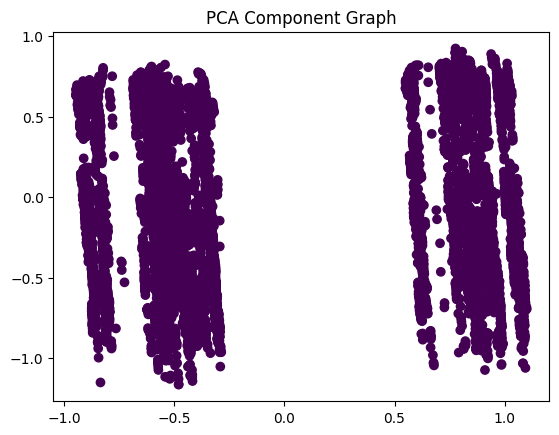

In [ ]:
plot = plt.scatter(X[:,0], X[:,1], c=Y)
plt.title("PCA Component Graph")
plt.show()

In [ ]:
#applying DBSCAN based clustering with kernel density to select cluster with most similarity
dbscan = DBSCAN(eps=0.9, min_samples=8)#generating DBSCAN clustering
labels = dbscan.fit_predict(X)
# Kernel Density Estimation for each cluster
unique_labels = np.unique(labels)
choosen_cluster = []
choosen_labels = []
for label in unique_labels:
    if label == -1:  # Noise points
        continue
    cluster_data = X[labels == label]
    YY = Y1[labels == label]
    kde = KernelDensity(bandwidth=0.5).fit(cluster_data)#applying kernel density
    density = kde.score_samples(cluster_data)
    choosen_cluster.append(cluster_data)
    choosen_labels.append(YY)
similarity = 100000
selected = -1
for i in range(0, len(choosen_cluster)):
    cluster1 = choosen_cluster[i]
    for j in range(0, len(choosen_cluster)):
        if i != j:
            cluster2 = choosen_cluster[j]
            sim = cosine_similarity(cluster1, cluster2)#measuring similarity between clusters
            if np.mean(sim) < similarity:
                similarity = np.mean(sim)
                selected = i
X = choosen_cluster[selected]
Y = choosen_labels[selected]
print("Number of selected Clusters = "+str(len(choosen_cluster)))
print("Cluster values with most similarity = "+str(X))

Number of selected Clusters = 2
Cluster values with most similarity = [[-8.40036376e-01  7.50821105e-01 -1.09147217e-01 ...  5.44867410e-02
  -1.50901200e-01 -5.75822244e-02]
 [-8.84150193e-01  7.29006560e-01  2.50242144e-02 ...  9.08868760e-03
   3.61587519e-05 -5.27387833e-02]
 [-8.87518987e-01  7.23276161e-01  3.75553518e-02 ... -1.33755190e-02
   1.24752472e-02 -2.18834424e-02]
 ...
 [-5.57262529e-01  6.08370273e-02  5.71791199e-01 ... -5.92058525e-02
  -2.38358446e-01  2.50879267e-02]
 [-5.46656000e-01 -6.56272073e-02  5.71974238e-01 ...  1.08118452e-01
  -2.53522415e-01 -5.87609381e-02]
 [-5.45304410e-01 -1.11615112e-01  5.79932244e-01 ... -1.32480869e-02
  -2.46743849e-01  4.09950587e-02]]


In [ ]:
Y = Y.reshape(-1, 1)
Y = scaler1.fit_transform(Y)
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Train & Test Dataset Split")
print("Total records found in selected cluster = "+str(X.shape[0]))
print("Total features found in selected cluster = "+str(X.shape[1]))
print("80% records used to train algorithms : "+str(X_train.shape[0]))
print("20% records features used to test algorithms : "+str(X_test.shape[0]))

Train & Test Dataset Split
Total records found in selected cluster = 6051
Total features found in selected cluster = 15
80% records used to train algorithms : 4840
20% records features used to test algorithms : 1211


In [ ]:
#defining global variables to save algorithm performnace metrics
rsquare = []
mape = []
rmse = []

In [ ]:
#function to calculate MAPE, RMSE and R2Square from predicted and true values
def calculateMetrics(algorithm, predict, test_labels):
    mape_error = mean_absolute_error(test_labels, predict)
    r2_scores = r2_score(np.asarray(test_labels), np.asarray(predict))
    rmse_error = sqrt(mean_squared_error(test_labels, predict))
    rsquare.append(r2_scores)
    mape.append(mape_error)
    rmse.append(rmse_error)
    predict = predict.reshape(-1, 1)
    predict = scaler1.inverse_transform(predict)
    test_label = scaler1.inverse_transform(test_labels)
    predict = predict.ravel()
    test_label = test_label.ravel()
    print()
    print(algorithm+" MAPE : "+str(mape_error))
    print(algorithm+" RMSE : "+str(rmse_error))
    print(algorithm+" R2 : "+str(r2_scores))
    print()
    for i in range(0, 10):
        print("True Cellular Traffic : "+str(test_label[i])+" Predicted Cellular Traffic : "+str(predict[i]))
    plt.figure(figsize=(5,3))
    plt.plot(test_label[0:100], color = 'red', label = 'True Traffic')
    plt.plot(predict[0:100], color = 'green', label = 'Predicted Traffic')
    plt.title(algorithm+' Cellular Traffic Forecasting Graph')
    plt.xlabel('Number of Test Samples')
    plt.ylabel('Cellular Traffic Forecasting')
    plt.legend()
    plt.show()


AM-CTP SVM MAPE : 0.0628931241128801
AM-CTP SVM RMSE : 0.0854885858492447
AM-CTP SVM R2 : 0.8520491395028728

True Cellular Traffic : 13813792.0 Predicted Cellular Traffic : 22292017.475844644
True Cellular Traffic : 70063460.0 Predicted Cellular Traffic : 49320513.2963748
True Cellular Traffic : 1588768.0 Predicted Cellular Traffic : 3458300.458206507
True Cellular Traffic : 106811300.0 Predicted Cellular Traffic : 93549440.37674618
True Cellular Traffic : 66728256.0 Predicted Cellular Traffic : 69671116.23703702
True Cellular Traffic : 106666530.0 Predicted Cellular Traffic : 66383102.45142541
True Cellular Traffic : 59596990.0 Predicted Cellular Traffic : 73882452.27130902
True Cellular Traffic : 20823776.0 Predicted Cellular Traffic : 45014230.474727616
True Cellular Traffic : 115662400.0 Predicted Cellular Traffic : 101359724.66281047
True Cellular Traffic : 2207296.0 Predicted Cellular Traffic : -377850.61095657595


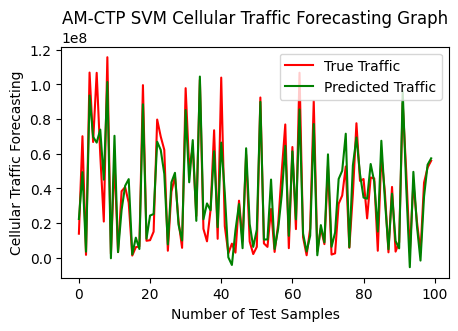

In [ ]:
#training propose AM-CTP SVM algorithm
X_train, X_test1, y_train, y_test1 = train_test_split(X, Y, test_size=0.1)
svm_cls = svm.SVR()
svm_cls.fit(X_train, y_train.ravel())
#perform prediction on test datat
predict = svm_cls.predict(X_test)
#call this function to calculate performance metrics
calculateMetrics("AM-CTP SVM", predict, y_test)


AM-CTP Linear Regression MAPE : 0.09514749146420168
AM-CTP Linear Regression RMSE : 0.1253389278914083
AM-CTP Linear Regression R2 : 0.681966271731065

True Cellular Traffic : 13813792.0 Predicted Cellular Traffic : 10782031.340307955
True Cellular Traffic : 70063460.0 Predicted Cellular Traffic : 48550936.03994692
True Cellular Traffic : 1588768.0 Predicted Cellular Traffic : -4885672.13019661
True Cellular Traffic : 106811300.0 Predicted Cellular Traffic : 67995130.35403799
True Cellular Traffic : 66728256.0 Predicted Cellular Traffic : 63763698.02516377
True Cellular Traffic : 106666530.0 Predicted Cellular Traffic : 50107770.40744541
True Cellular Traffic : 59596990.0 Predicted Cellular Traffic : 62499909.488772504
True Cellular Traffic : 20823776.0 Predicted Cellular Traffic : 37488816.90964802
True Cellular Traffic : 115662400.0 Predicted Cellular Traffic : 85667349.44585042
True Cellular Traffic : 2207296.0 Predicted Cellular Traffic : -1566321.1569900692


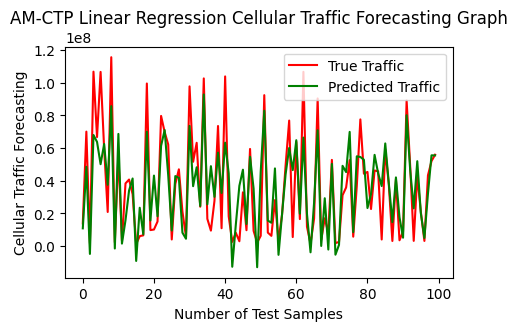

In [ ]:
#training propose AM-CTP Linear Regression algorithm
lr_cls = LinearRegression()
lr_cls.fit(X_train, y_train.ravel())
#perform prediction on test datat
predict = lr_cls.predict(X_test)
#call this function to calculate performance metrics
calculateMetrics("AM-CTP Linear Regression", predict, y_test)


AM-CTP Decision Tree MAPE : 0.005435003295288209
AM-CTP Decision Tree RMSE : 0.026767623329899317
AM-CTP Decision Tree R2 : 0.9854948957669106

True Cellular Traffic : 13813792.0 Predicted Cellular Traffic : 13813792.0
True Cellular Traffic : 70063460.0 Predicted Cellular Traffic : 70063460.0
True Cellular Traffic : 1588768.0 Predicted Cellular Traffic : 1588768.0
True Cellular Traffic : 106811300.0 Predicted Cellular Traffic : 106811300.0
True Cellular Traffic : 66728256.0 Predicted Cellular Traffic : 66728256.0
True Cellular Traffic : 106666530.0 Predicted Cellular Traffic : 106666530.0
True Cellular Traffic : 59596990.0 Predicted Cellular Traffic : 59596990.0
True Cellular Traffic : 20823776.0 Predicted Cellular Traffic : 20823776.0
True Cellular Traffic : 115662400.0 Predicted Cellular Traffic : 115662400.0
True Cellular Traffic : 2207296.0 Predicted Cellular Traffic : 2207296.0


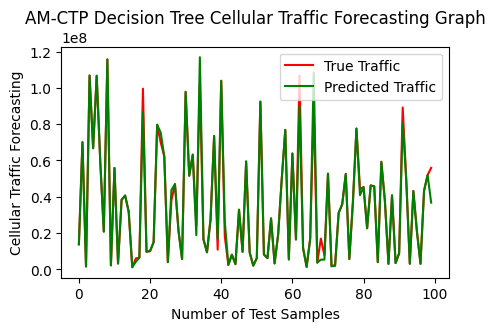

In [ ]:
#training propose AM-CTP Linear Regression algorithm
dt_cls = DecisionTreeRegressor()
dt_cls.fit(X_train, y_train.ravel())
#perform prediction on test datat
predict = dt_cls.predict(X_test)
#call this function to calculate performance metrics
calculateMetrics("AM-CTP Decision Tree", predict, y_test)


AM-CTP Light Gradient Boosting MAPE : 0.056680976291534735
AM-CTP Light Gradient Boosting RMSE : 0.08311313891065943
AM-CTP Light Gradient Boosting R2 : 0.8601570430980975

True Cellular Traffic : 13813792.0 Predicted Cellular Traffic : 8585799.825379264
True Cellular Traffic : 70063460.0 Predicted Cellular Traffic : 48910764.40093002
True Cellular Traffic : 1588768.0 Predicted Cellular Traffic : 2411582.9910549293
True Cellular Traffic : 106811300.0 Predicted Cellular Traffic : 90922550.80191797
True Cellular Traffic : 66728256.0 Predicted Cellular Traffic : 67974738.17697574
True Cellular Traffic : 106666530.0 Predicted Cellular Traffic : 70035573.40391223
True Cellular Traffic : 59596990.0 Predicted Cellular Traffic : 68366195.4329679
True Cellular Traffic : 20823776.0 Predicted Cellular Traffic : 40321475.17992376
True Cellular Traffic : 115662400.0 Predicted Cellular Traffic : 90894124.85717918
True Cellular Traffic : 2207296.0 Predicted Cellular Traffic : 2322637.2812523767


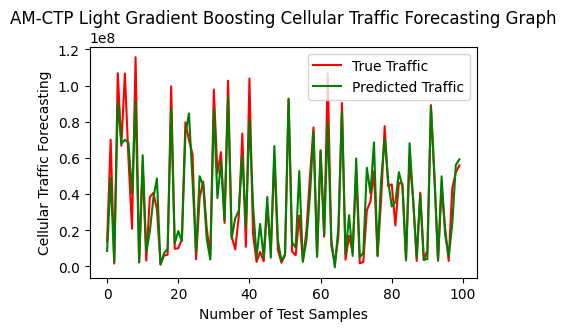

In [ ]:
#training propose AM-CTP Linear Regression algorithm
gb_cls = GradientBoostingRegressor()
gb_cls.fit(X_train, y_train.ravel())
#perform prediction on test datat
predict = gb_cls.predict(X_test)
#call this function to calculate performance metrics
calculateMetrics("AM-CTP Light Gradient Boosting", predict, y_test)

In [ ]:
#best AM-CTP model Selection phase
#display all algorithm performnace
algorithms = ['SVM', 'Linear Regression', 'Decision Tree', 'Light Gradient Boosting']
data = []
for i in range(len(rmse)):
    data.append([algorithms[i], rsquare[i], rmse[i], mape[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'R2 Score', 'RMSE', 'MAPE'])
print("Best AM-CTP selected model is Decision Tree")
data

Best AM-CTP selected model is Decision Tree


,Algorithm Name,R2 Score,RMSE,MAPE
0,SVM,0.852049,0.085489,0.062893
1,Linear Regression,0.681966,0.125339,0.095147
2,Decision Tree,0.985495,0.026768,0.005435
3,Light Gradient Boosting,0.860157,0.083113,0.056681



Extension XGBoost MAPE : 0.011612948311985213
Extension XGBoost RMSE : 0.021733261603263797
Extension XGBoost R2 : 0.9904379492450741

True Cellular Traffic : 13813792.0 Predicted Cellular Traffic : 12595819.0
True Cellular Traffic : 70063460.0 Predicted Cellular Traffic : 65837156.0
True Cellular Traffic : 1588768.0 Predicted Cellular Traffic : 2122046.5
True Cellular Traffic : 106811300.0 Predicted Cellular Traffic : 106441976.0
True Cellular Traffic : 66728256.0 Predicted Cellular Traffic : 67253130.0
True Cellular Traffic : 106666530.0 Predicted Cellular Traffic : 104325690.0
True Cellular Traffic : 59596990.0 Predicted Cellular Traffic : 61114316.0
True Cellular Traffic : 20823776.0 Predicted Cellular Traffic : 26303558.0
True Cellular Traffic : 115662400.0 Predicted Cellular Traffic : 115444440.0
True Cellular Traffic : 2207296.0 Predicted Cellular Traffic : 1944664.9


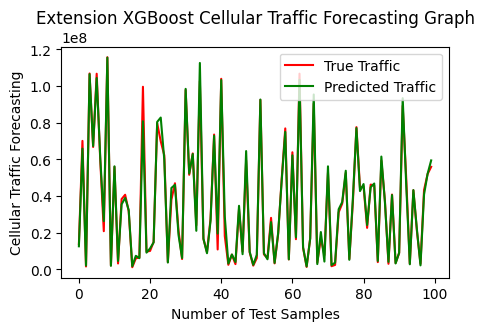

In [ ]:
#training extension XGBOOST algorithm
from xgboost import XGBRegressor
xgboost = XGBRegressor(n_estimators=200)
xgboost.fit(X_train, y_train.ravel())
#perform prediction on test datat
predict = xgboost.predict(X_test)
#call this function to calculate performance metrics
calculateMetrics("Extension XGBoost", predict, y_test)

In [ ]:
#display all algorithm performnace in tabular format
algorithms = ['SVM', 'Linear Regression', 'Decision Tree', 'Light Gradient Boosting', 'Extension XGBoost']
data = []
for i in range(len(rmse)):
    data.append([algorithms[i], rsquare[i], rmse[i], mape[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'R2 Score', 'RMSE', 'MAPE'])
data

,Algorithm Name,R2 Score,RMSE,MAPE
0,SVM,0.852049,0.085489,0.062893
1,Linear Regression,0.681966,0.125339,0.095147
2,Decision Tree,0.985495,0.026768,0.005435
3,Light Gradient Boosting,0.860157,0.083113,0.056681
4,Extension XGBoost,0.990438,0.021733,0.011613


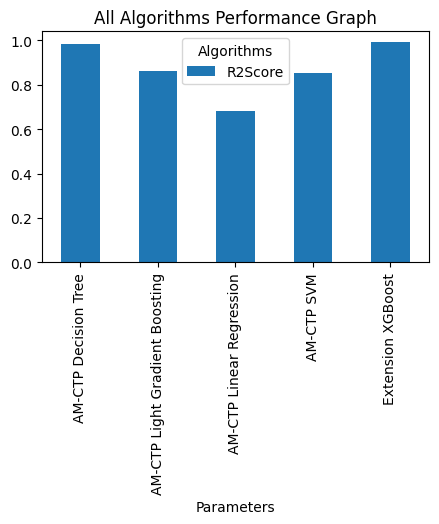

In [ ]:
#all algorithms R2 Score Graph
df = pd.DataFrame([['AM-CTP SVM','R2Score',rsquare[0]],
                    ['AM-CTP Linear Regression','R2Score',rsquare[1]],
                    ['AM-CTP Decision Tree','R2Score',rsquare[2]],
                    ['AM-CTP Light Gradient Boosting','R2Score',rsquare[3]],
                    ['Extension XGBoost','R2Score',rsquare[4]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot(index="Parameters", columns="Algorithms", values="Value").plot(kind='bar', figsize=(5,3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [ ]:
#read test values from test dataset file and then predict cellular traffic demand
test_data = pd.read_csv("testData.csv")#reading test data values
temp = test_data.values
test_data['time'] = pd.to_datetime(test_data['time'])#convert datetime to numeric format
test_data['year'] = test_data['time'].dt.year
test_data['month'] = test_data['time'].dt.month
test_data['day'] = test_data['time'].dt.day
test_data['hour'] = test_data['time'].dt.hour
test_data['minute'] = test_data['time'].dt.minute
test_data['second'] = test_data['time'].dt.second
for i in range(len(label_encoder)):
    le = label_encoder[i]
    test_data[le[0]] = pd.Series(le[1].transform(test_data[le[0]].astype(str)))#encode all str columns to numeric
#handling and removing missing values
test_data.fillna(0, inplace = True)
test_data.drop(['time','netmode', 'datarate'], axis = 1,inplace=True)#drop ir-relevant columns
test_data = test_data.values
test_data = selector.transform(test_data)#select features using select k-best
test_data = pca.transform(test_data)#dimension reduction using PCA
predict = xgboost.predict(test_data)#perform prediction using XGBOOST on test data
predict = predict.reshape(-1, 1)
predict = scaler1.inverse_transform(predict)#denormalize pedicted demand
for i in range(len(predict)):
    print("Test Data = "+str(temp[i])+" Forecasted Traffic Demand = "+str(predict[i,0]))
    print()


Test Data = ['2018-04-18 05:37:37' 47.8565 13.1316 589.0 True -11.0 706823 9.0 4.0
 271.0 -57.0 19.0 'LTE' -76.0 54345630.0 '2018-04-18-0730' 440
 '2018-04-18-0730' 1.0 -0.0003633499 7.6293945e-06 nan] Forecasted Traffic Demand = 232771.14

Test Data = ['2018-04-18 05:37:38' 47.856506 13.13124 588.0 True -11.0 706823 13.0 4.0
 271.0 -57.0 19.0 'LTE' -75.0 53309024.0 '2018-04-18-0730' 441
 '2018-04-18-0730' 1.0 -0.0003604889 7.6293945e-06 nan] Forecasted Traffic Demand = 232771.14

Test Data = ['2018-09-03 15:46:09' 47.85265 13.107607 563.0 True -10.0 710662 9.0 4.0
 282.0 -53.0 19.0 'LTE' -71.0 14129120.0 '2018-09-03-1736' 461
 '2018-09-03-1736' 1.0 0.00038814545 6.484985e-05 nan] Forecasted Traffic Demand = 232771.14

Test Data = ['2018-09-03 15:46:10' 47.852715 13.108002 563.0 False -10.0 710662 10.0
 4.0 282.0 -53.0 19.0 'LTE' -72.0 21394888.0 '2018-09-03-1736' 462
 '2018-09-03-1736' 1.0 0.00039482117 6.484985e-05 nan] Forecasted Traffic Demand = 232771.14

Test Data = ['2019-01-03 

/tmp/ipykernel_415/1852416950.py:95: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


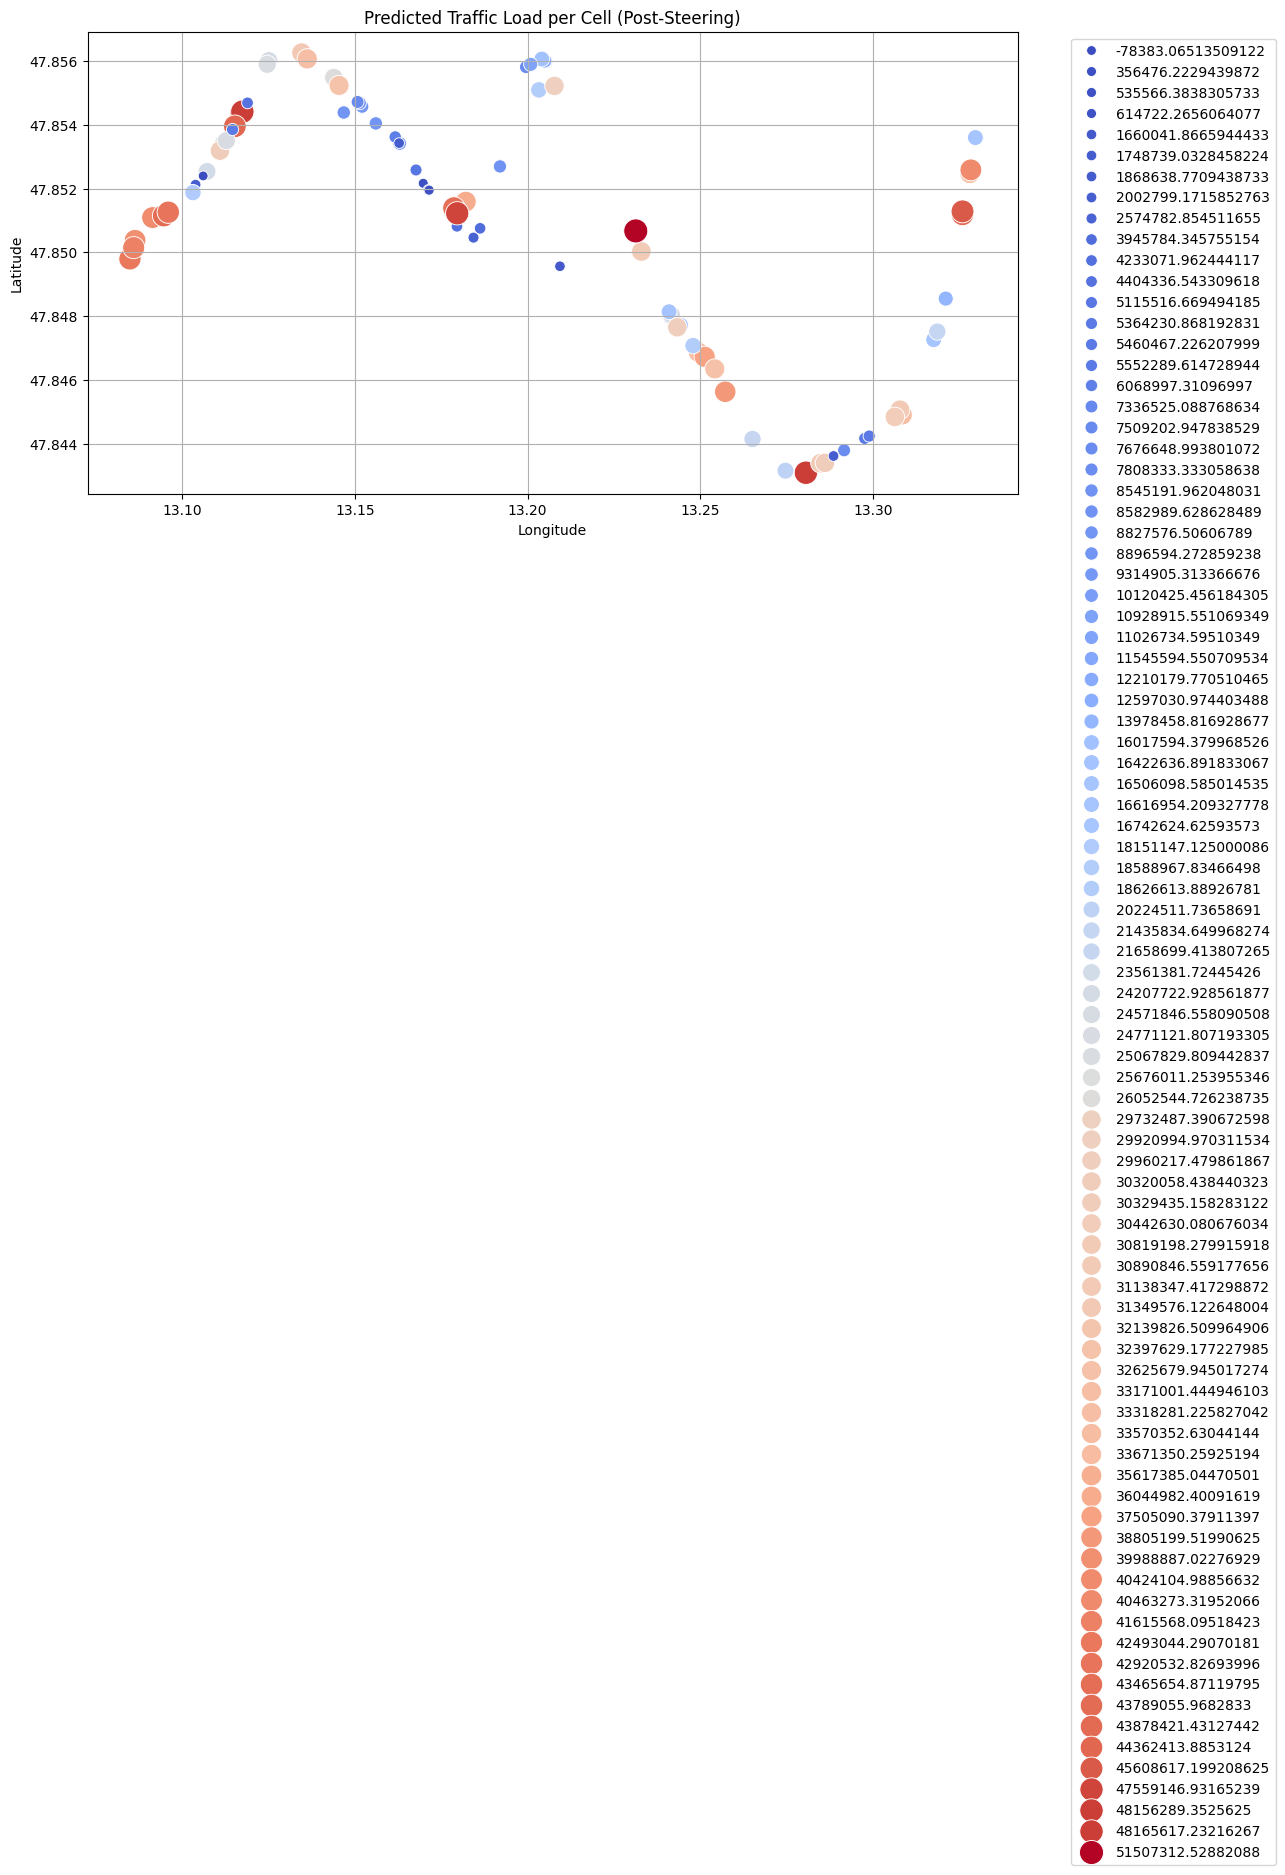

In [ ]:
# === Traffic Steering with Visualization (Real Dataset) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("SRFG-v1.csv")

# Select features and target
features = ['rsrq', 'rsrp', 'rssi', 'sinr', 'signal', 'pci', 'lat', 'long', 'ele', 'netmode', 'technology']
target = 'datarate'

# Drop rows with missing values
df = df.dropna(subset=features + [target, 'cell_id'])

# One-hot encode categorical features
df_encoded = pd.get_dummies(df[features], drop_first=True)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
X = pd.DataFrame(X_scaled, columns=df_encoded.columns)

# Target and identifier
y = df[target].values
X['cell_id'] = df['cell_id'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X.drop(columns='cell_id'), y, test_size=0.2, random_state=42)

# Train model
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Predict traffic
df['predicted_datarate'] = model.predict(X.drop(columns='cell_id'))

# Congestion logic
threshold = np.percentile(df['predicted_datarate'], 85)
df['congested'] = df['predicted_datarate'] > threshold

# Simulate neighbors (random for now)
cell_ids = df['cell_id'].unique()
neighbor_map = {
    cell: list(np.random.choice(cell_ids[cell_ids != cell], size=min(3, len(cell_ids)-1), replace=False))
    for cell in cell_ids
}

# Apply traffic steering
df['steer_to'] = None
for idx, row in df.iterrows():
    if row['congested']:
        current_cell = row['cell_id']
        neighbors = neighbor_map.get(current_cell, [])
        neighbor_loads = [df[df['cell_id'] == n]['predicted_datarate'].mean() for n in neighbors if not df[df['cell_id'] == n].empty]
        if neighbor_loads:
            best_neighbor = neighbors[np.argmin(neighbor_loads)]
            df.at[idx, 'steer_to'] = best_neighbor

# Evaluate model
y_pred = model.predict(X_test)


# === Visualization ===
# Aggregate data per cell
plot_df = df.groupby('cell_id').agg({
    'predicted_datarate': 'mean',
    'lat': 'mean',
    'long': 'mean',
    'congested': 'max'
}).reset_index()

# Scatter plot of traffic
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=plot_df,
    x='long',
    y='lat',
    hue='predicted_datarate',
    size='predicted_datarate',
    palette='coolwarm',
    sizes=(50, 300),
    legend='full'
)
plt.title("Predicted Traffic Load per Cell (Post-Steering)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Optional: Save full result
df.to_csv("traffic_steering_results.csv", index=False)
